# 5.3 Observational Validation with ZFOURGE

This notebook confirms theoretical trends using observational ZFOURGE data by tracking how the average galaxy in each UVJ region evolves with increasing Type 1 AGN contribution. It also includes the CIGALE decomposed population analysis. Results correspond to Section 5.3 of the paper.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src import config
from glass import photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Observational ZFOURGE Composites (Fig 7, 8, Table 4)

Loading the pre-generated observational composite data and plotting UVJ density and average region tracks.

C:\Users\Mitchell\AppData\Local\Temp\ipykernel_29616\4287345648.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])


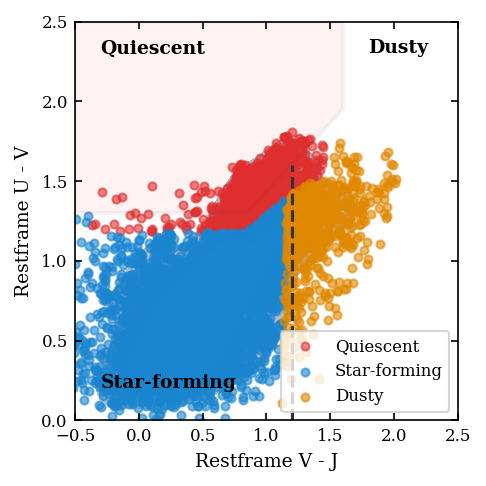

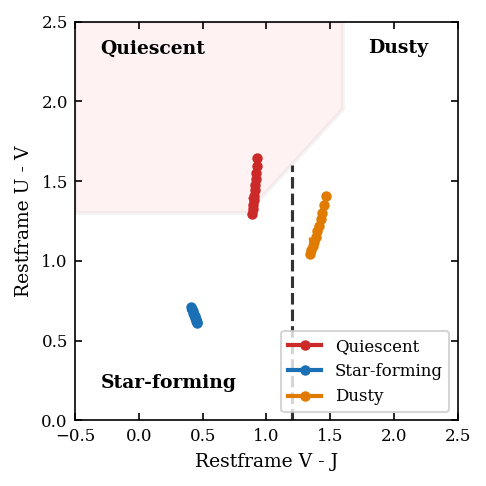

In [2]:
obs_csv_path = os.path.join(config.PROCESSED_DATA_DIR, '..', '..', 'outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')
if not os.path.exists(obs_csv_path):
    obs_csv_path = os.path.join(os.path.abspath('..'), 'outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')

if os.path.exists(obs_csv_path):
    df_obs = pd.read_csv(obs_csv_path, index_col=0)
    df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])

    # Fig 7: UVJ Density at Alpha=50%
    uv_50 = df_obs['U_50'] - df_obs['V_50']
    vj_50 = df_obs['V_50'] - df_obs['J_50']
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram(vj_50, uv_50, classifications=df_obs['Classification'],
                                   show_density=True, ax=ax, title="",
                                   scatter_colors=('#E03030', '#1A85D0', '#E08800'))
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_evolution_Type1AGN_ZFOURGE_0_5.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

    # Fig 8: Average Region Tracks — vibrant print-safe colours
    regions = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    colors  = {0: '#CC2929',   1: '#1A6FB5',       2: '#E07B00'}
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    for cid, name in regions.items():
        sub = df_obs[df_obs['Classification'] == cid]
        if len(sub) == 0: continue
        tvj = [sub[f'V_{a}'].mean() - sub[f'J_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        tuv = [sub[f'U_{a}'].mean() - sub[f'V_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        ax.plot(tvj, tuv, marker='o', color=colors[cid], label=name, lw=2, markersize=4)
        ax.annotate('', xy=(tvj[-1], tuv[-1]), xytext=(tvj[0], tuv[0]),
                    arrowprops=dict(arrowstyle="->", color=colors[cid], lw=1.5))
    ax.legend(loc='lower right')
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'ZFOURGE_obsevational_composites_fluxesType1AGN_uvj_diagram_pathsubplot.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"Observational composite file not found at: {obs_csv_path}")

## 2. Population Vector Offset Analysis (Table 4)

Calculating the mean vector displacement for each population within the observational ZFOURGE composites.

In [3]:
if os.path.exists(obs_csv_path):
    alphas = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    table_data = []
    for a in alphas:
        row = {'AGN Contribution (%)': a}
        for cid, name in regions.items():
            sub = df_obs[df_obs['Classification'] == cid]
            if len(sub) == 0:
                row[name] = np.nan
                continue
            vj_a = sub[f'V_{a}'] - sub[f'J_{a}']
            uv_a = sub[f'U_{a}'] - sub[f'V_{a}']
            vj_0 = sub['V_0'] - sub['J_0']
            uv_0 = sub['U_0'] - sub['V_0']
            offset = analysis.calculate_mean_vector_offset(vj_a.values, uv_a.values, vj_0.values, uv_0.values)
            row[name] = offset
        table_data.append(row)
    
    df_table4 = pd.DataFrame(table_data)
    display(df_table4.round(3))
    df_table4.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'population_vectoroffset.csv'), index=False)
    
    latex_table = df_table4.to_latex(index=False, float_format="%.3f", caption=r"Mean vector offsets for each of the selection regions in the UVJ colour space.", label="tab:population_vectoroffset")
    with open(os.path.join(config.PROCESSED_DATA_DIR, 'population_vectoroffset.tex'), 'w') as f:
        f.write(latex_table)
    print("Exported Population Vector Offset table.")

,AGN Contribution (%),Quiescent,Star-forming,Dusty
0,0,0.000,0.000,0.000
1,10,0.047,0.017,0.056
2,20,0.090,0.034,0.106
3,30,0.131,0.049,0.152
4,40,0.168,0.063,0.194
5,50,0.203,0.077,0.233
6,60,0.236,0.090,0.269
7,70,0.267,0.102,0.302
8,80,0.296,0.114,0.333
9,90,0.324,0.125,0.362


Exported Population Vector Offset table.


## 3. CIGALE Decomposed Population Analysis (Fig 9, 10, 11)

Analyzing the UVJ shift of the entire ZFOURGE population when AGN light is removed via CIGALE SED decomposition.

C:\Users\Mitchell\AppData\Local\Temp\ipykernel_29616\2796938909.py:3: DtypeWarning: Columns (0: Use2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cig = pd.read_csv(cigale_csv)


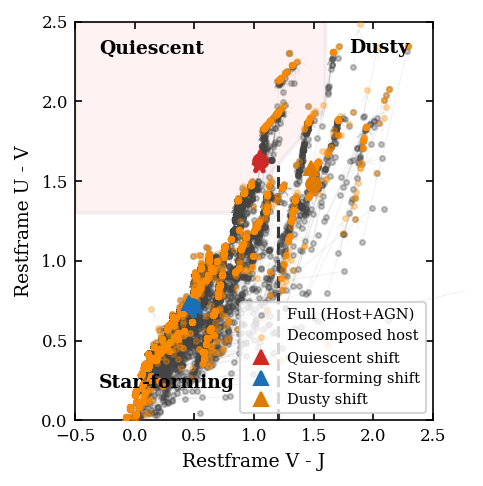

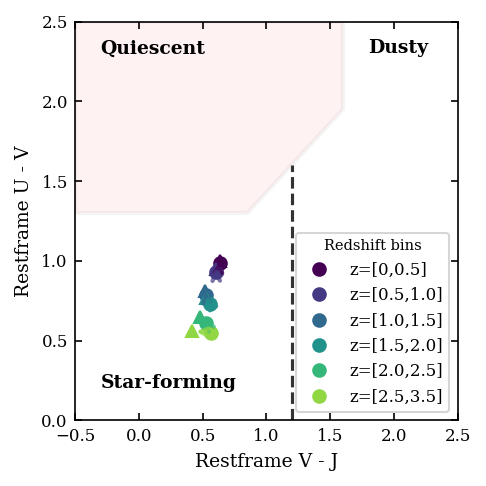

In [4]:
cigale_csv = os.path.join(os.path.abspath('..'), 'datasets', 'full_zfourge_decomposed', 'zfourge_full_final.csv')
if os.path.exists(cigale_csv):
    df_cig = pd.read_csv(cigale_csv)
    z_col = 'zpk_x' if 'zpk_x' in df_cig.columns else 'zpk'

    # Fig 9: Combined full+decomposed with per-galaxy faint arrows and bold mean vectors
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    # Faint per-galaxy arrows: full → decomposed
    for _, row in df_cig.dropna(subset=['VJ_Full', 'UV_Full', 'VJ_Decomposed', 'UV_Decomposed']).iterrows():
        ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                    xytext=(row['VJ_Full'], row['UV_Full']),
                    arrowprops=dict(arrowstyle='->', color='#888888', alpha=0.12, lw=0.5))

    # Scatter both populations
    ax.scatter(df_cig['VJ_Full'],       df_cig['UV_Full'],       c='#444444',   s=6, alpha=0.3, label='Full (Host+AGN)',  zorder=3)
    ax.scatter(df_cig['VJ_Decomposed'], df_cig['UV_Decomposed'], c='darkorange', s=6, alpha=0.3, label='Decomposed host', zorder=3)

    # Bold mean vectors per UVJ region (classify by full-galaxy position)
    classifications_full = photometry.classify_uvj(df_cig['VJ_Full'], df_cig['UV_Full'])
    region_colors = {0: '#CC2929', 1: '#1A6FB5', 2: '#E07B00'}
    region_names  = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    for cid in [0, 1, 2]:
        mask = classifications_full == cid
        if mask.sum() < 3: continue
        mvj_f = df_cig.loc[mask, 'VJ_Full'].mean()
        muv_f = df_cig.loc[mask, 'UV_Full'].mean()
        mvj_d = df_cig.loc[mask, 'VJ_Decomposed'].mean()
        muv_d = df_cig.loc[mask, 'UV_Decomposed'].mean()
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(mvj_f, muv_f, 'o', color=region_colors[cid], markersize=7, zorder=6)
        ax.plot(mvj_d, muv_d, '^', color=region_colors[cid], markersize=7, zorder=6,
                label=f'{region_names[cid]} shift')

    ax.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_CIGALE_FullDecomp_Vectors.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

    # Fig 11: Redshift Divergence — mean full vs decomposed positions per redshift bin
    bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    cmap = plt.cm.viridis
    for i, (z_min, z_max) in enumerate(bins):
        sub = df_cig[(df_cig[z_col] >= z_min) & (df_cig[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.legend(loc='lower right', title="Redshift bins", title_fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_agn_evolution_CIGALE_ZFOURGE_comparison_redshift.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("CIGALE summary table not found.")